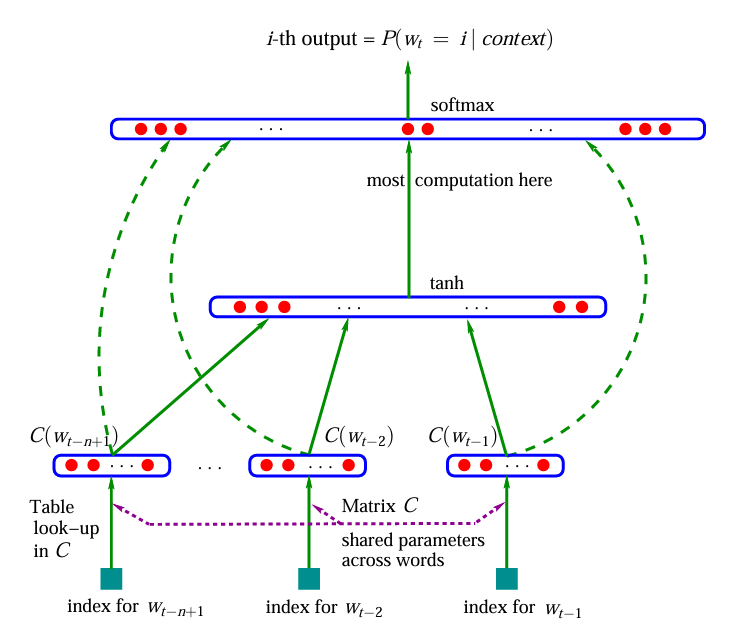

In [ ]:
zhs = open('data/names1/names1.txt','r').read().splitlines()
pinyins = open('data/names1/names1_pinyin_components.txt','r').read().splitlines()
pinyins_to_chars = open('data/names1/pinyin_components_to_hanzi_chars1.txt','r').read().splitlines()

i=0
for zh,p,ch in zip(zhs[:10],pinyins[:10],pinyins_to_chars[:10]):
    print(f'{i:02d}: {zh:5} {p:25} {ch}')
    i+=1

len(zhs),len(pinyins),len(pinyins_to_chars)

00: 倪|子宁  n i | z i n ing           n i	倪
01: 宋|云深  s ong | y un sh en        z i	子
02: 尤|听澜  y ou | t ing l an         n ing	宁
03: 唐|承安  t ang | ch eng _ an       s ong	宋
04: 龙|长宁  l ong | zh ang n ing      y un	云 韵
05: 田|清玄  t ian | q ing x uan       sh en	深 沈 申
06: 柯|川   k e | ch uan              y ou	尤 游
07: 郑|灵微  zh eng | l ing w ei       t ing	听
08: 任|瑶音  r en | y ao y in          l an	澜 岚 兰
09: 汪|音   w ang | y in              t ang	唐 棠 汤


(12000, 12000, 188)

In [2]:
# set(''.join(pinyins))
tokens = [p.split() for p in pinyins]
token_list = sorted({'.'} | {t for token in tokens for t in token})
token_list_len = len(token_list)

stoi = {s:i for i,s in enumerate(token_list)}
itos = {i:s for i,s in enumerate(token_list)}


print(pinyins[:2])
print(tokens[:2])
print(sorted(set([t for token in tokens[:2] for t in token])))

print(itos)
print(stoi)
print(token_list_len)

['n i | z i n ing', 's ong | y un sh en']
[['n', 'i', '|', 'z', 'i', 'n', 'ing'], ['s', 'ong', '|', 'y', 'un', 'sh', 'en']]
['en', 'i', 'ing', 'n', 'ong', 's', 'sh', 'un', 'y', 'z', '|']
{0: '.', 1: '_', 2: 'a', 3: 'ai', 4: 'an', 5: 'ang', 6: 'ao', 7: 'b', 8: 'c', 9: 'ch', 10: 'd', 11: 'e', 12: 'ei', 13: 'en', 14: 'eng', 15: 'f', 16: 'g', 17: 'h', 18: 'i', 19: 'ia', 20: 'ian', 21: 'iang', 22: 'iao', 23: 'ie', 24: 'in', 25: 'ing', 26: 'iong', 27: 'iu', 28: 'j', 29: 'k', 30: 'l', 31: 'm', 32: 'n', 33: 'o', 34: 'ong', 35: 'ou', 36: 'p', 37: 'q', 38: 'r', 39: 's', 40: 'sh', 41: 't', 42: 'u', 43: 'ua', 44: 'uai', 45: 'uan', 46: 'uang', 47: 'ue', 48: 'ui', 49: 'un', 50: 'uo', 51: 'v', 52: 'w', 53: 'x', 54: 'y', 55: 'z', 56: 'zh', 57: '|'}
{'.': 0, '_': 1, 'a': 2, 'ai': 3, 'an': 4, 'ang': 5, 'ao': 6, 'b': 7, 'c': 8, 'ch': 9, 'd': 10, 'e': 11, 'ei': 12, 'en': 13, 'eng': 14, 'f': 15, 'g': 16, 'h': 17, 'i': 18, 'ia': 19, 'ian': 20, 'iang': 21, 'iao': 22, 'ie': 23, 'in': 24, 'ing': 25, 'iong': 26

In [3]:
block_size = 3 # 上下文长度
train_count = 10000
X,Y = [],[]
for t in tokens[:train_count]:
    # print(['.']*block_size + t + ['.'])
    # print(t + ['.'])

    str1 = ['.']*block_size + t + ['.']
    str2 = t + ['.']

    i=0
    for _,y in zip(str1,str2):
        # print(str1[i:i+block_size],y)
        # print([stoi[str1[j]] for j in range(i,i+block_size)],stoi[y])
        X.append([stoi[str1[j]] for j in range(i,i+block_size)])
        Y.append(stoi[y])
        i+=1

import torch
X=torch.tensor(X)
Y=torch.tensor(Y)
#X,Y,
X.shape,Y.shape,X.dtype,Y.dtype

(torch.Size([77428, 3]), torch.Size([77428]), torch.int64, torch.int64)

In [4]:
embedding_dim = 2
E = torch.randn(token_list_len,embedding_dim) # [58,embedding_dim]

In [5]:
E[5] # 等价于 one_hot([1,58])@[58,embedding_dim]=[1,embedding_dim]
test_index = 10
X[test_index],torch.cat([E[X[test_index][i]] for i in range(block_size)]).view(block_size,embedding_dim),E[X][test_index]

(tensor([ 0, 39, 34]),
 tensor([[ 1.0023, -0.1731],
         [-1.1579, -0.5263],
         [ 1.6699, -0.0423]]),
 tensor([[ 1.0023, -0.1731],
         [-1.1579, -0.5263],
         [ 1.6699, -0.0423]]))

In [6]:
X[5],[E[57],E[55],E[18]],E[X][5]

(tensor([57, 55, 18]),
 [tensor([-0.5878, -0.8784]),
  tensor([-0.5653, -0.2968]),
  tensor([0.1216, 1.3813])],
 tensor([[-0.5878, -0.8784],
         [-0.5653, -0.2968],
         [ 0.1216,  1.3813]]))

In [7]:
hidden_dim = 100
emb = E[X]
W1 = torch.randn(block_size*embedding_dim, hidden_dim)
b1 = torch.randn(hidden_dim)
h=torch.tanh(emb.view(-1,block_size*embedding_dim)@W1+b1)
h.shape

torch.Size([77428, 100])

In [8]:
W2 = torch.randn(hidden_dim,token_list_len)
b2 = torch.randn(token_list_len)
logits = h@W2+b2
counts = logits.exp()
prob = counts/counts.sum(1,keepdim=True)
prob.shape,prob[0],prob[0].sum()

(torch.Size([77428, 58]),
 tensor([1.5234e-11, 1.1096e-12, 1.2050e-10, 2.5218e-07, 1.1313e-05, 3.4892e-07,
         1.3828e-06, 3.8656e-04, 6.9212e-10, 3.6716e-02, 7.8970e-08, 2.2163e-06,
         2.0970e-11, 1.8858e-11, 4.2515e-04, 4.8307e-07, 1.1365e-05, 4.5100e-01,
         1.2435e-13, 3.3700e-08, 3.0139e-09, 8.6071e-05, 1.6245e-11, 4.1649e-08,
         2.0879e-06, 4.5290e-09, 1.8308e-04, 6.9599e-05, 3.2782e-06, 5.5753e-09,
         9.9574e-08, 8.6027e-06, 3.3042e-10, 1.7302e-10, 1.9581e-05, 7.8836e-12,
         3.7549e-09, 5.0217e-09, 1.1373e-12, 3.6192e-15, 1.0174e-05, 4.3872e-10,
         5.1375e-10, 4.0271e-11, 1.0635e-10, 1.9799e-02, 3.4300e-12, 4.0637e-11,
         1.2069e-03, 4.9006e-01, 2.7863e-07, 5.1677e-11, 6.4440e-09, 3.1596e-08,
         8.0607e-07, 1.1582e-08, 2.2200e-07, 1.2184e-07]),
 tensor(1.))

In [9]:
Y,prob[0,32],prob[1,18],prob[torch.arange(X.shape[0]),Y]

(tensor([32, 18, 57,  ..., 28, 49,  0]),
 tensor(3.3042e-10),
 tensor(6.5364e-12),
 tensor([3.3042e-10, 6.5364e-12, 1.0078e-08,  ..., 9.6888e-07, 6.9487e-09,
         1.9755e-04]))

In [10]:
loss = -prob[torch.arange(X.shape[0]),Y].log().mean()
loss

tensor(16.5200)

In [11]:
import torch.nn.functional as F
F.cross_entropy(logits,Y)

tensor(16.5200)

In [12]:
X.shape,Y.shape

(torch.Size([77428, 3]), torch.Size([77428]))

In [4]:
lre = torch.linspace(-3,0,1000)
lrs = 10**lre
lrs

tensor([0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012,
        0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0013, 0.0013, 0.0013,
        0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0014,
        0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014,
        0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015,
        0.0015, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016,
        0.0016, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017,
        0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0019,
        0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0020, 0.0020,
        0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0021, 0.0021, 0.0021, 0.0021,
        0.0021, 0.0021, 0.0021, 0.0022, 

In [14]:
import torch.nn.functional as F
embedding_dim = 2
hidden_dim = 100
batch_size = 32

g = torch.Generator().manual_seed(0)
E = torch.randn((token_list_len, embedding_dim),generator=g)
W1 = torch.randn((block_size*embedding_dim, hidden_dim),generator=g)
b1 = torch.randn(hidden_dim,generator=g)
W2 = torch.randn((hidden_dim,token_list_len),generator=g)
b2 = torch.randn(token_list_len,generator=g)

parameters=[E,W1,b1,W2,b2]
for p in parameters:
    p.requires_grad = True
print('params count: ',sum(p.nelement() for p in parameters))
# forward pass
lri=[]
lrei=[]
lossi=[]
for i in range(1000):
    
    batch_idxs = torch.randint(0,train_count,(batch_size,),generator=g)
    emb = E[X[batch_idxs]]
    h = torch.tanh(emb.view(-1,block_size*embedding_dim)@W1+b1)
    logits = h@W2+b2
    loss = F.cross_entropy(logits,Y[batch_idxs])

    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = lrs[i]
    for p in parameters:
        p.data += -lr*p.grad
    
    # track stats
    lri.append(lr)
    lrei.append(lre[i])
    lossi.append(loss.item())

    print(f'loss:{loss.item()}')

params count:  6674
loss:21.56779670715332
loss:20.199125289916992
loss:20.718461990356445
loss:19.474796295166016
loss:18.474939346313477
loss:19.568889617919922
loss:18.95841407775879
loss:16.500564575195312
loss:21.64748764038086
loss:17.801963806152344
loss:17.097497940063477
loss:19.607248306274414
loss:18.83200454711914
loss:19.39887809753418
loss:18.738534927368164
loss:18.658260345458984
loss:20.454458236694336
loss:18.81819725036621
loss:20.663829803466797
loss:19.315980911254883
loss:18.31820297241211
loss:17.771345138549805
loss:20.06805992126465
loss:17.585500717163086
loss:21.056564331054688
loss:21.782442092895508
loss:17.308582305908203
loss:20.200559616088867
loss:20.498687744140625
loss:19.07317352294922
loss:21.502355575561523
loss:20.66333770751953
loss:20.297683715820312
loss:16.61280059814453
loss:18.512371063232422
loss:21.638620376586914
loss:17.86143684387207
loss:17.282604217529297
loss:23.099273681640625
loss:21.294893264770508
loss:19.254802703857422
loss:21.

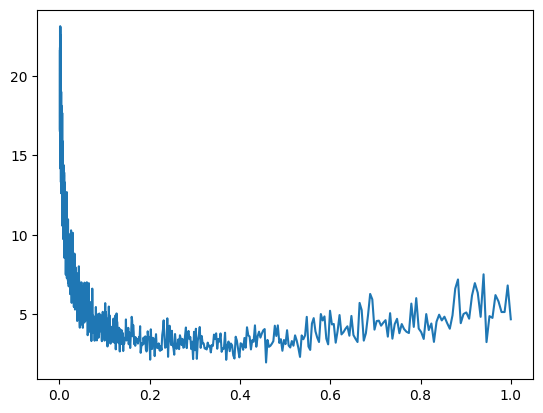

In [17]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.plot(lri,lossi)


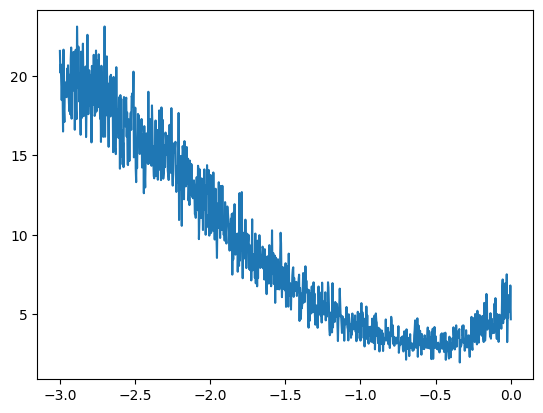

In [18]:
plt.plot(lrei,lossi)

In [19]:
10**-0.5

0.31622776601683794

In [ ]:
logits.max(1)

In [ ]:
Y

In [20]:
embedding_dim = 2
hidden_dim = 100
batch_size = 32

g = torch.Generator().manual_seed(0)
E = torch.randn((token_list_len, embedding_dim),generator=g)
W1 = torch.randn((block_size*embedding_dim, hidden_dim),generator=g)
b1 = torch.randn(hidden_dim,generator=g)
W2 = torch.randn((hidden_dim,token_list_len),generator=g)
b2 = torch.randn(token_list_len,generator=g)

parameters=[E,W1,b1,W2,b2]
for p in parameters:
    p.requires_grad = True

# forward pass
for i in range(20000):
    
    batch_idxs = torch.randint(0,train_count,(batch_size,))
    emb = E[X[batch_idxs]]
    h = torch.tanh(emb.view(-1,block_size*embedding_dim)@W1+b1)
    logits = h@W2+b2
    loss = F.cross_entropy(logits,Y[batch_idxs])

    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.3 if i<10000 else 0.03
    for p in parameters:
        p.data += -lr*p.grad
    
    if(i%1000==0):
        print(f'{i:6d}: loss={loss.item()}')


     0: loss=17.407785415649414
  1000: loss=2.0602529048919678
  2000: loss=1.7202891111373901
  3000: loss=1.9304221868515015
  4000: loss=1.884783148765564
  5000: loss=2.5070290565490723
  6000: loss=1.5515516996383667
  7000: loss=1.1902614831924438
  8000: loss=1.5275235176086426
  9000: loss=1.6320654153823853
 10000: loss=1.80413818359375
 11000: loss=1.6370930671691895
 12000: loss=1.7827433347702026
 13000: loss=1.6735438108444214
 14000: loss=1.4881806373596191
 15000: loss=1.6838111877441406
 16000: loss=1.1718261241912842
 17000: loss=1.9339499473571777
 18000: loss=1.5145453214645386
 19000: loss=1.5216830968856812


In [21]:
# 训练集 80% -> 优化模型权重
# 验证集 10% -> 调整超参数
# 测试集 10% -> 测试模型泛化性和准确率
import torch
block_size = 3 # 上下文长度
def build_dataset(data):
    X,Y = [],[]
    for t in data:
        # print(['.']*block_size + t + ['.'])
        # print(t + ['.'])

        str1 = ['.']*block_size + t + ['.']
        str2 = t + ['.']

        i=0
        for _,y in zip(str1,str2):
            # print(str1[i:i+block_size],y)
            # print([stoi[str1[j]] for j in range(i,i+block_size)],stoi[y])
            X.append([stoi[str1[j]] for j in range(i,i+block_size)])
            Y.append(stoi[y])
            i+=1


    X=torch.tensor(X)
    Y=torch.tensor(Y)
    print(X.shape,Y.shape,X.dtype,Y.dtype)
    return X,Y

import random
random.seed(0)
random.shuffle(tokens)
n1 = int(0.8*len(tokens))
n2 = int(0.9*len(tokens))

Xtr,Ytr   = build_dataset(tokens[:n1])
Xdev,Ydev = build_dataset(tokens[n1:n2])
Xte,Yte   = build_dataset(tokens[n2:])

torch.Size([74388, 3]) torch.Size([74388]) torch.int64 torch.int64
torch.Size([9262, 3]) torch.Size([9262]) torch.int64 torch.int64
torch.Size([9266, 3]) torch.Size([9266]) torch.int64 torch.int64


In [ ]:
tokens.__len__(),tokens[:n1].__len__(),tokens[n1:n2].__len__(),tokens[n2:].__len__(), Ytr.shape[0]+Ydev.shape[0]+Yte.shape[0]

In [31]:
embedding_dim = 2
hidden_dim = 100
batch_size = 32

g = torch.Generator().manual_seed(0)
E = torch.randn((token_list_len, embedding_dim),generator=g)
W1 = torch.randn((block_size*embedding_dim, hidden_dim),generator=g)
b1 = torch.randn(hidden_dim,generator=g)
W2 = torch.randn((hidden_dim,token_list_len),generator=g)
b2 = torch.randn(token_list_len,generator=g)

parameters=[E,W1,b1,W2,b2]
for p in parameters:
    p.requires_grad = True
lr_base = 0.3

In [32]:
# train
iter_count = 20000
stepi = []
lossi = []
for i in range(iter_count):
    # forward pass
    batch_idxs = torch.randint(0,Xtr.shape[0],(batch_size,))
    emb = E[Xtr[batch_idxs]]
    h = torch.tanh(emb.view(-1,block_size*embedding_dim)@W1+b1)
    logits = h@W2+b2
    loss = F.cross_entropy(logits,Ytr[batch_idxs])

    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = lr_base if i<iter_count/2 else lr_base/10
    for p in parameters:
        p.data += -lr*p.grad
    
    # track stats
    stepi.append(i)
    lossi.append(loss.item())

    # print
    if(i%1000==0):
        print(f'{i:6d}: loss={loss.item()}')


     0: loss=21.472312927246094
  1000: loss=2.7165277004241943
  2000: loss=1.8245691061019897
  3000: loss=1.946108102798462
  4000: loss=2.1684439182281494
  5000: loss=2.0141899585723877
  6000: loss=1.959160327911377
  7000: loss=2.2350568771362305
  8000: loss=1.9563535451889038
  9000: loss=1.8466216325759888
 10000: loss=1.9478479623794556
 11000: loss=1.3801841735839844
 12000: loss=1.660783290863037
 13000: loss=1.6601738929748535
 14000: loss=1.255326747894287
 15000: loss=1.7472785711288452
 16000: loss=1.2704505920410156
 17000: loss=1.590464472770691
 18000: loss=1.3647270202636719
 19000: loss=1.6170005798339844


tensor(1.4380, grad_fn=<NllLossBackward0>)


tensor(1.4484, grad_fn=<NllLossBackward0>)

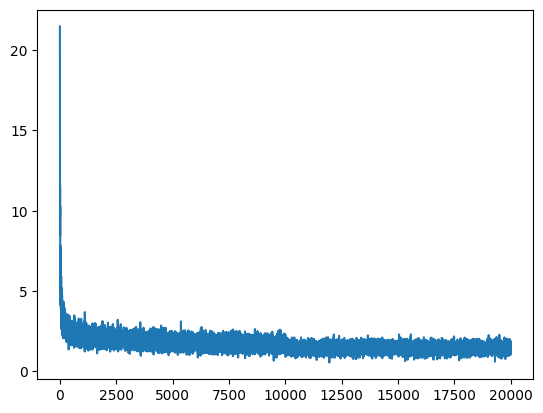

In [35]:
# vailiate
plt.plot(stepi,lossi)

emb = E[Xtr]
h = torch.tanh(emb.view(-1,block_size*embedding_dim)@W1+b1)
logits = h@W2+b2
loss = F.cross_entropy(logits,Ytr)
print(loss)

emb = E[Xdev]
h = torch.tanh(emb.view(-1,block_size*embedding_dim)@W1+b1)
logits = h@W2+b2
loss = F.cross_entropy(logits,Ydev)
loss

In [40]:
E.shape,E[:,0].data

(torch.Size([58, 2]),
 tensor([-2.4106, -1.9763,  1.0507,  0.3814,  1.5941, -0.0914,  1.1008,  1.8589,
          0.7688,  1.5905,  0.8478,  0.2432,  1.4512,  1.0220,  0.2905,  2.3848,
          1.2244,  1.5588,  0.5785,  0.0352,  0.5243,  0.3483,  0.8670,  0.5093,
          0.2325,  0.2677,  0.5336,  0.2925, -0.7331,  2.7673, -1.1264,  2.7901,
         -2.5786,  0.8754, -0.3206,  1.6685,  2.5310, -1.6734, -0.7009, -0.3259,
          0.9615, -0.0647,  0.8378,  0.5275, -0.3794,  0.6097, -0.4011,  1.2108,
          0.3143, -0.1033,  0.3532,  0.3071,  0.7037, -0.9519,  0.1178,  0.0463,
          0.4090, -0.8062]))

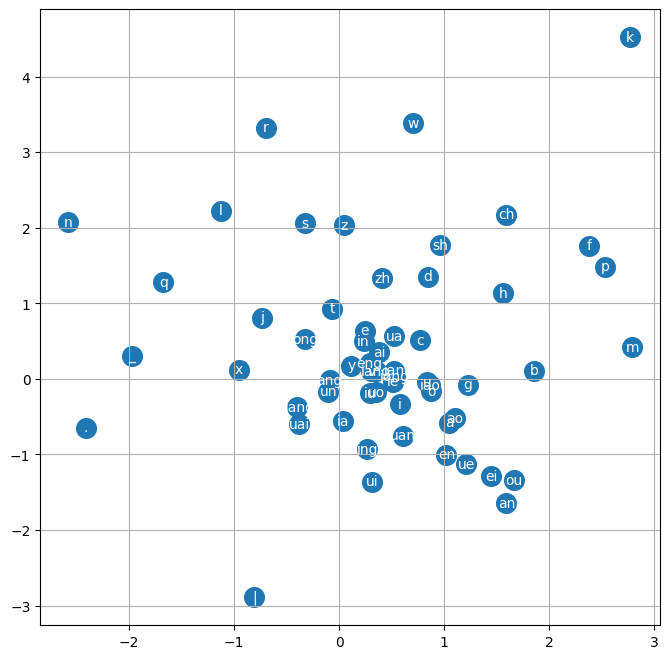

In [44]:
plt.figure(figsize=(8,8))
plt.scatter(E[:,0].data,E[:,1].data,s=200)
for i in range(E.shape[0]):
    plt.text(E[i,0].item(),E[i,1].item(),itos[i],ha='center',va='center',color='white')
plt.grid('minor')

In [86]:
# 采样
g = torch.Generator().manual_seed(0)

samples=[]
names=[]
for i in range(100):
    has_first_name = False
    out = []
    context = [0]*3  #'...'起始
    # print(context)
    while True:
        emb = E[torch.tensor([context])]

        # print(emb)

        h = torch.tanh(emb.view(1,-1)@W1+b1)
        # print(h.shape)
        logits = h@W2+b2
        probs = F.softmax(logits,dim=1)
        # print(probs.shape, probs[0].sum())
        ix = torch.multinomial(probs,num_samples=1,replacement=True,generator=g).item()
        char = itos[ix]
        # 确保每次采样一个姓氏一个名
        if char=='.':
            if has_first_name:
                break
            else:
                continue
        if char=='|':
            if not has_first_name:
                has_first_name = True
            else:
                break 
        context = context[1:]+[ix]       
        out.append(char)
        
        # #小于5个字
        # if len(out)>=4*2 :
        #     break
    samples.append(out)
    

i=0        
for o in samples:
    print(f'{i:03d}:{o}')
    i+=1 

000:['t', 'ian', '|', 'y', 'ing', 'l', 'an']
001:['sh', 'i', '|', 'm', 'ai']
002:['zh', 'u', '|', 'm', 'ing', 'x', 'uan']
003:['l', 'v', '|', 'j', 'ing', 'h', 'e']
004:['h', 'ou', '|', 'g', 'ui', 'w', 'an']
005:['d', 'ai', '|', 'q', 'ing', 'q', 'iu']
006:['d', 'uan', '|', 'm', 'ing', 'zh', 'ao']
007:['x', 'ue', '|', 'y', 'an']
008:['j', 'iang', '|', 'y', 'u', 'w', 'ong']
009:['m', 'o', '|', 'y', 'ue', 'q', 'ing']
010:['q', 'ian', '|', 'q', 'ing', 'y', 'uan']
011:['w', 'ei', '|', 'x', 'iu', 'l', 'i']
012:['g', 'ao', '|', 'l', 'an', 'n', 'ing']
013:['l', 'in', '|', 'x', 'uan']
014:['zh', 'ong', '|', 'sh', 'ou', 'zh', 'en']
015:['p', 'eng', '|', 'x', 'uan']
016:['zh', 'ong', '|', 'l', 'in']
017:['b', 'o', '|', 't', 'ing', 'j', 'in']
018:['t', 'ong', '|', 'sh', 'i', 'q', 'iu']
019:['w', 'u', '|', 'g', 'ao', 'b']
020:['d', 'u', '|', 'l', 'an']
021:['j', 'i', '|', 'w', 'u', 'n', 'ian']
022:['zh', 'ang', '|', 'g', 'ui']
023:['t', 'ian', '|', 'y', 'ao']
024:['l', 'ong', '|', 't', 'ing', 'l', '

In [ ]:
# 解码成中文
INITIALS = {
    '_', 'b','p','m','f','d','t','n','l','g','k','h',
    'j','q','x','r','z','c','s','y','w','zh','ch','sh'
}

FINALS = {
    'a','o','e','i','u','v',
    'ai','ei','ui','ao','ou','iu','ie','ue','er',
    'an','en','in','un','vn',
    'ang','eng','ing','ong',
    'ia','iao','ian','iang','iong',
    'ua','uo','uai','uan','uang'
}
def is_valid(tokens):
    
    # 只能有一个姓氏
    if tokens.count('|') != 1:
        return False

    # 必须有一个姓氏和一个名
    sep = tokens.index('|')
    if sep == 0 or sep == len(tokens) - 1:
        return False

    # 确保声母和韵母配对
    parts = tokens[:sep] + tokens[sep + 1:]
    if len(parts) % 2 != 0:
        return False

    # # 小于5个汉字
    # if len(parts)/2 > 5:
    #     return False

    # 必须在声韵表中
    for i in range(0, len(parts), 2):
        if parts[i] not in INITIALS:
            return False
        if parts[i + 1] not in FINALS:
            return False

    return True


i=0
for flag in [is_valid(o) for o in samples]:
    if not flag:
        print(f'{i}: {samples[i]}')
    
    i+=1
    

19: ['w', 'u', '|', 'g', 'ao', 'b']
87: ['f', 'u', '|', 'ch', 'u', 'y']


In [128]:
import random
def load_component_char_mapping(path):
    mapping = {}

    with open(path, encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            key, chars_text = line.split('\t', 1)
            mapping[key] = chars_text.split()

    return mapping

mapping = load_component_char_mapping('data/names1/pinyin_components_to_hanzi_chars1.txt')
print(len(mapping),mapping.get('h an'))

def samples_to_names(samples, mapping, rng=random):
    for i, tokens in enumerate(samples):
        try:
            sep = tokens.index('|')
        except ValueError:
            # 1. 没有 '|' 符号，属于严重格式错误，保留 INVALID
            print(f'{i:03d}: [<Invaild 1: No \'|\' >] --> [<None>]')
            continue

        left_part, right_part = [], []
        valid = True

        for side in (tokens[:sep], tokens[sep + 1:]):
            # 2. 长度不是偶数，属于格式错误，保留 INVALID
            if len(side) % 2 != 0:
                valid = False
                break
            
            l_chars, r_chars = [], []
            for j in range(0, len(side), 2):
                pinyin = side[j] + side[j + 1]
                key = f"{side[j]} {side[j + 1]}"
                choices = mapping.get(key)
                
                # 如果 mapping 里面没有，直接用原始拼音
                if choices:
                    l_chars.append(rng.choice(choices))
                else:
                    l_chars.append(pinyin)
                    
                r_chars.append(pinyin)
            
            left_part.append(''.join(l_chars))
            right_part.append(' '.join(r_chars))

        if not valid:
            print(f'{i:03d}: [<Invaild 2: 声韵母不匹配>] --> [<None>]')
        else:
            print(f'{i:03d}: [{" | ".join(right_part):25}] --> [{"|".join(left_part)}]')

# 调用方式保持不变
samples_to_names(samples, mapping)


188 ['含', '韩', '涵', '寒']
000: [tian | ying lan          ] --> [田|影兰]
001: [shi | mai                ] --> [施|mai]
002: [zhu | ming xuan          ] --> [竹|明玄]
003: [lv | jing he             ] --> [吕|景禾]
004: [hou | gui wan            ] --> [侯|归晚]
005: [dai | qing qiu           ] --> [戴|晴秋]
006: [duan | ming zhao         ] --> [段|明照]
007: [xue | yan                ] --> [薛|阎]
008: [jiang | yu wong          ] --> [蒋|于wong]
009: [mo | yue qing            ] --> [墨|岳清]
010: [qian | qing yuan         ] --> [倩|清渊]
011: [wei | xiu li             ] --> [卫|修厉]
012: [gao | lan ning           ] --> [高|澜宁]
013: [lin | xuan               ] --> [临|轩]
014: [zhong | shou zhen        ] --> [钟|守甄]
015: [peng | xuan              ] --> [彭|玄]
016: [zhong | lin              ] --> [钟|林]
017: [bo | ting jin            ] --> [卜|听靳]
018: [tong | shi qiu           ] --> [童|施邱]
019: [<Invaild 2: 声韵母不匹配>] --> [<None>]
020: [du | lan                 ] --> [杜|澜]
021: [ji | wu nian             ] --> [季|武念]
022: [zhang 